# Survivor Data Set: An Exploration
## Project Overview

We seek to understand the underlying themes in the reality TV gameshow "Survivor". The show is currently airing it's 50th season, but the gameplay we see in the later seasons is very different from the early seasons of the show. Survivor is a gameshow about physical challenges and mental strength, but fundamentally it is a show about relationships with others. In a game where the goal is to "Outwit, Outplay, Outlast", what does this actually translate to? In order to win you need the votes of the jury, which is made up of the players you had a hand in voting off of the tribe.

The thing that makes Survivor so interesting is how different every season is, and how the game is always evolving. In early seasons, loyalty and morals were valued, and the gameplay was relatively simple. As time went on, players got more conniving, and blindsides and backstabbing became the norm. But what is most interesting is that as the gameplay changed, so did the mentality of the players. Playing fair isn't enough to win anymore. 

Through this data we hope to find answers to some of these questions:
- What does it take Outwit, Outplay, and Outlast?
- What decisions to winners make? 
- What decisions do losers make?
- How have the decisions made by winners and losers changed as the game has evolved?
- Are there trends that predict performance?
- Are there qualities that predict performance?
- Have there been changes in these trends/qualities over time?

## Data Description and Source
The original survivoR dataset is in R, [original data set](https://github.com/doehm/survivoR/tree/master/data). We will be using a modified version of this dataset that has been converted to CSV files found here: [Survivor Data Set](https://github.com/rfordatascience/tidytuesday/tree/master/data/2021/2021-06-01)

The original dataset has 23 R data files, while the dataset that's been converted to CSV only has 5 of these. 

The 5 csv files are:
- Summary
- Challanges
- Castaways
- Viewers
- Jury Votes


# Initial CSV Data
The sections below walk through each CSV in the same order: **Initial CSV exploration**, **Cleaning needs**, **Methods**, and **Results**.


## Setup: imports and loading

Import **pandas** and load all tables from the TidyTuesday CSV mirror.


In [1]:
# Obligatory pandas import
import pandas as pd

In [2]:
# Each table is available as a CSV from the TidyTuesday GitHub mirror
base_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2021/2021-06-01/"

# Load the main tables
summary_df     = pd.read_csv(base_url + "summary.csv")
challenges_df  = pd.read_csv(base_url + "challenges.csv")
castaways_df   = pd.read_csv(base_url + "castaways.csv")
viewers_df     = pd.read_csv(base_url + "viewers.csv")
jury_votes_df  = pd.read_csv(base_url + "jury_votes.csv")

## Table: Summary


### Initial CSV exploration

#### Relevance:
- Primary data set for information on seasons, winners, and dates.
- Useful for determining winners and trends over time.

#### Size:
- 40 rows
- 19 columns
- 6.1 KB

#### Column descriptions (English):
- **Season Name**: The name of the season
- **Season**: The season number
- **Location**: The geographical location of the show
- **Country**: The country where the season takes place
- **Tribe Setup**: How players are divided into tribes (teams)
- **Full Name**: The name of the player
- **Winner**: The winner of the season
- **Runner Ups**: Second place
- **Final Vote**: The vote split for the winner
- **Time Slot**: Day and time of week when episodes aired
- **Premiered**: Date when the season premiered
- **Ended**: Date when the season ended
- **Filming Strated**: Date when filming started (note: this spelling matches the CSV column label)
- **Filming Ended**: Date when filming ended
- **Viewers Finale**: Number of viewers for the final episode
- **Viewers Reunion**: Number of viewers for the reunion (contestant retrospective)
- **Viewers Mean**: Average viewership for episodes
- **Rank**: Viewer final ranking of the contestant

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [3]:
summary_df.info()
summary_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season_name      40 non-null     str    
 1   season           40 non-null     int64  
 2   location         40 non-null     str    
 3   country          40 non-null     str    
 4   tribe_setup      40 non-null     str    
 5   full_name        40 non-null     str    
 6   winner           40 non-null     str    
 7   runner_ups       40 non-null     str    
 8   final_vote       40 non-null     str    
 9   timeslot         40 non-null     str    
 10  premiered        40 non-null     str    
 11  ended            40 non-null     str    
 12  filming_started  40 non-null     str    
 13  filming_ended    40 non-null     str    
 14  viewers_premier  40 non-null     float64
 15  viewers_finale   40 non-null     float64
 16  viewers_reunion  40 non-null     float64
 17  viewers_mean     38 non-null 

,season_name,season,location,country,tribe_setup,full_name,winner,runner_ups,final_vote,timeslot,premiered,ended,filming_started,filming_ended,viewers_premier,viewers_finale,viewers_reunion,viewers_mean,rank
0,Survivor: Borneo,1,"Pulau Tiga, Sabah, Malaysia",Malaysia,Two tribes of eight new players,Richard Hatch,Richard,Kelly Wiglesworth,4-3,Wednesday 8:00 pm,2000-05-31,2000-08-23,2000-03-13,2000-04-20,15.51,51.69,36.70,28.30,2.0
1,Survivor: The Australian Outback,2,"Herbert River at Goshen Station, Queensland, A...",Australia,Two tribes of eight new players,Tina Wesson,Tina,Colby Donaldson,4-3,Thursday 8:00 pm,2001-01-28,2001-05-03,2000-10-23,2000-12-03,45.37,36.35,28.01,29.80,1.0
2,Survivor: Africa,3,"Shaba National Reserve, Kenya",Kenya,Two tribes of eight new players,Ethan Zohn,Ethan,Kim Johnson,5-2,Thursday 8:00 pm,2001-10-11,2002-01-10,2001-07-11,2001-08-18,23.84,27.26,19.05,20.69,8.0
3,Survivor: Marquesas,4,"Nuku Hiva, Marquesas Islands, French Polynesia",Polynesia,Two tribes of eight new players,Vecepia Towery,Vecepia,Neleh Dennis,4-3,Thursday 8:00 pm,2002-02-28,2002-05-19,2001-11-12,2001-12-20,23.19,25.87,19.05,20.77,6.0
4,Survivor: Thailand,5,"Ko Tarutao, Satun Province, Thailand",Thailand,Two tribes of eight new players; picked by the...,Brian Heidik,Brian,Clay Jordan,4-3,Thursday 8:00 pm,2002-09-19,2002-12-19,2002-06-10,2002-07-18,23.05,24.08,20.43,21.21,4.0


### Cleaning

All steps use `clean_summary_df`, created with `summary_df.copy()` in the first cleaning code cell, so `summary_df` stays the untouched load. From raw inspection, we fix:

- `premiered`, `ended`, `filming_started`, and `filming_ended`: strings → datetimes
- `timeslot`: split into `weekday` and `air_time`
- `viewers_mean` and `rank`: median fill for `viewers_mean` and missing `rank` kept with `has_rank` for training filters


### Methods

The following code cells implement the cleaning steps on `clean_summary_df`.


In [4]:
# Working copy for cleaning; summary_df remains the raw CSV load
clean_summary_df = summary_df.copy()

In [5]:
# View the timeslot column entries
clean_summary_df['timeslot'].value_counts()

timeslot
Wednesday 8:00 pm    21
Thursday 8:00 pm     19
Name: count, dtype: int64

In [6]:
# Extract weekday and time text from timeslot
parts = clean_summary_df["timeslot"].str.extract(r"(\w+)\s+(.+)")
clean_summary_df["weekday"] = parts[0]
clean_summary_df["air_time_raw"] = parts[1]

# Parse time text into a time value
clean_summary_df["air_time"] = pd.to_datetime(
    clean_summary_df["air_time_raw"].str.strip().str.lower(),
    format="%I:%M %p",
    errors="coerce"
).dt.time

# Drop the timeslot column and airtime_raw column
clean_summary_df = clean_summary_df.drop(columns=["timeslot", "air_time_raw"])

clean_summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   season_name      40 non-null     str    
 1   season           40 non-null     int64  
 2   location         40 non-null     str    
 3   country          40 non-null     str    
 4   tribe_setup      40 non-null     str    
 5   full_name        40 non-null     str    
 6   winner           40 non-null     str    
 7   runner_ups       40 non-null     str    
 8   final_vote       40 non-null     str    
 9   premiered        40 non-null     str    
 10  ended            40 non-null     str    
 11  filming_started  40 non-null     str    
 12  filming_ended    40 non-null     str    
 13  viewers_premier  40 non-null     float64
 14  viewers_finale   40 non-null     float64
 15  viewers_reunion  40 non-null     float64
 16  viewers_mean     38 non-null     float64
 17  rank             38 non-null 

In [7]:
# Convert the premiered, ended, filming_started, and filming_ended columns to datetime
clean_summary_df['premiered'] = pd.to_datetime(clean_summary_df['premiered'])
clean_summary_df['ended'] = pd.to_datetime(clean_summary_df['ended'])
clean_summary_df['filming_started'] = pd.to_datetime(clean_summary_df['filming_started'])
clean_summary_df['filming_ended'] = pd.to_datetime(clean_summary_df['filming_ended'])

# Show the updated dataframe
clean_summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season_name      40 non-null     str           
 1   season           40 non-null     int64         
 2   location         40 non-null     str           
 3   country          40 non-null     str           
 4   tribe_setup      40 non-null     str           
 5   full_name        40 non-null     str           
 6   winner           40 non-null     str           
 7   runner_ups       40 non-null     str           
 8   final_vote       40 non-null     str           
 9   premiered        40 non-null     datetime64[us]
 10  ended            40 non-null     datetime64[us]
 11  filming_started  40 non-null     datetime64[us]
 12  filming_ended    40 non-null     datetime64[us]
 13  viewers_premier  40 non-null     float64       
 14  viewers_finale   40 non-null     float64       
 15  vi

In [8]:
# View the null values in viewers_mean and rank
clean_summary_df[clean_summary_df['viewers_mean'].isna() | clean_summary_df['rank'].isna()]

,season_name,season,location,country,tribe_setup,full_name,winner,runner_ups,final_vote,premiered,ended,filming_started,filming_ended,viewers_premier,viewers_finale,viewers_reunion,viewers_mean,rank,weekday,air_time
38,Survivor: Island of the Idols,39,"Mamanuca Islands, Fiji",Fiji,Two tribes of ten new players. Past winners Ro...,Tommy Sheehan,Tommy,"Dean Kowalski, Noura Salman",8-2-0,2019-09-25,2019-12-18,2019-03-21,2019-04-28,6.29,6.52,4.61,NaN,NaN,Wednesday,20:00:00
39,Survivor: Winners at War,40,"Mamanuca Islands, Fiji",Fiji,Two tribes of ten winners of past Survivor sea...,Tony Vlachos,Tony,"Natalie Anderson, Michele Fitzgerald",12-4-0,2020-02-12,2020-05-13,2019-05-22,2019-06-29,6.68,7.94,4.61,NaN,NaN,Wednesday,20:00:00


`rank` and `viewers_mean` are missing in the same two rows. We keep every season, so `viewers_mean` is filled with the median of non-missing values, `rank` stays NaN where unknown, and `has_rank` is True only when `rank` is present so rows without a label can be excluded when training a model that predicts `rank`.

In [9]:
# Median impute viewers_mean; keep missing rank and flag rows usable as labeled training data
viewers_median = clean_summary_df["viewers_mean"].median()
clean_summary_df["viewers_mean"] = clean_summary_df["viewers_mean"].fillna(
    viewers_median
)
clean_summary_df["has_rank"] = clean_summary_df["rank"].notna()

clean_summary_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   season_name      40 non-null     str           
 1   season           40 non-null     int64         
 2   location         40 non-null     str           
 3   country          40 non-null     str           
 4   tribe_setup      40 non-null     str           
 5   full_name        40 non-null     str           
 6   winner           40 non-null     str           
 7   runner_ups       40 non-null     str           
 8   final_vote       40 non-null     str           
 9   premiered        40 non-null     datetime64[us]
 10  ended            40 non-null     datetime64[us]
 11  filming_started  40 non-null     datetime64[us]
 12  filming_ended    40 non-null     datetime64[us]
 13  viewers_premier  40 non-null     float64       
 14  viewers_finale   40 non-null     float64       
 15  vi

### Results

**Summary:** Summary Data Frame

`clean_summary_df` keeps all 40 seasons with consistent dtypes and `weekday` / `air_time` from `timeslot`. After cleaning, `viewers_mean` has no nulls, from median imputation; `rank` is still null for the two incomplete seasons, so `has_rank` marks rows to include when `rank` is a target.


## Table: Challenges


### Initial CSV exploration

#### Relevance:
- Examines outcomes when contestants and tribes compete; these outcomes influence decisions when tribes vote contestants out.

#### Size:
- 5023 rows
- 8 columns
- 314.1 KB

#### Column descriptions (English):
- **season_name**: The season's name
- **season**: The season number
- **episode**: The episode number within the season
- **title**: The title of the episode
- **day**: The running day count since the game began
- **challenge_type**: Reward (a prize) or immunity (protection from being voted out)
- **winners**: The name of the contestant who won the challenge
- **winning_tribe**: The name of the tribe that won the challenge

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [10]:
print(challenges_df.info())
print(challenges_df.head())

# Challenge nulls before cleaning
challenge_nulls_before = challenges_df[["winners", "winning_tribe"]].isna().sum()
print("Nulls before cleaning:")
print(challenge_nulls_before)

<class 'pandas.DataFrame'>
RangeIndex: 5023 entries, 0 to 5022
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   season_name     5023 non-null   str  
 1   season          5023 non-null   int64
 2   episode         5023 non-null   int64
 3   title           5023 non-null   str  
 4   day             5023 non-null   int64
 5   challenge_type  5023 non-null   str  
 6   winners         5006 non-null   str  
 7   winning_tribe   3992 non-null   str  
dtypes: int64(3), str(5)
memory usage: 314.1 KB
None
                season_name  season  episode                   title  day  \
0  Survivor: Winners at War      40        1  Greatest of the Greats    2   
1  Survivor: Winners at War      40        1  Greatest of the Greats    2   
2  Survivor: Winners at War      40        1  Greatest of the Greats    2   
3  Survivor: Winners at War      40        1  Greatest of the Greats    2   
4  Survivor: Winners at War      40  

### Cleaning Needs / Methods

The following code cell houses all the challenge-row cleaning rules for `challenges_df`.


In [11]:
# Clean Version
challenges_cleaned_df = challenges_df.copy()

# Dropping rows that are placeholder / non-challenge rows
drop_mask = (
    # Survivor: Island of the Idols, episode 12
    ((challenges_cleaned_df["season"] == 39) &
     (challenges_cleaned_df["episode"] == 12) &
     (challenges_cleaned_df["day"] == 36) &
     (challenges_cleaned_df["challenge_type"] == "immunity") &
     (challenges_cleaned_df["winners"].isna())) |

    # Survivor: David vs. Goliath, episode 4
    ((challenges_cleaned_df["season"] == 37) &
     (challenges_cleaned_df["episode"] == 4) &
     (challenges_cleaned_df["day"] == 10) &
     (challenges_cleaned_df["challenge_type"] == "immunity") &
     (challenges_cleaned_df["winners"].isna()))
)

challenges_cleaned_df = challenges_cleaned_df.loc[~drop_mask].copy()

# Filling in rows where there truly was no immunity winner
no_winner_cases = [
    (32, 13),  # Kaoh Rong (Joe evacuated)
    (24, 6),   # One World (Colton evacuated)
    (21, 12),  # Nicaragua (NaOnka and Kelly quit)
    (19, 6),   # Samoa (Russell Swan evacuated)
    (12, 11),  # Panama (Bruce evacuated)
    (8, 3),    # All-Stars (Jenna quit)
    (8, 6),    # All-Stars (Sue quit)
    (2, 6)     # Australian Outback (Michael evacuated)
]

for season_num, episode_num in no_winner_cases:
    mask = (
        (challenges_cleaned_df["season"] == season_num) &
        (challenges_cleaned_df["episode"] == episode_num) &
        (challenges_cleaned_df["challenge_type"] == "immunity") &
        (challenges_cleaned_df["winners"].isna())
    )

    challenges_cleaned_df.loc[mask, "winners"] = "No challenge winner"
    challenges_cleaned_df.loc[mask, "winning_tribe"] = "Not applicable"

# If a winner exists but winning_tribe is missing, then tribe winner does not apply
tribe_not_applicable_mask = (
    challenges_cleaned_df["winners"].notna() &
    challenges_cleaned_df["winning_tribe"].isna()
)

challenges_cleaned_df.loc[tribe_not_applicable_mask, "winning_tribe"] = "Not applicable"

# Fixing Survivor: Blood vs. Water, episode 1
# Galang won the combined immunity/reward challenge, so restore the missing immunity winners
bvw_bad_immunity_rows = (
    (challenges_cleaned_df["season"] == 27) &
    (challenges_cleaned_df["episode"] == 1) &
    (challenges_cleaned_df["day"] == 1) &
    (challenges_cleaned_df["challenge_type"] == "immunity") &
    (challenges_cleaned_df["winners"].isna())
)

challenges_cleaned_df = challenges_cleaned_df.loc[~bvw_bad_immunity_rows].copy()

galang_members = [
    "Aras",
    "Colton",
    "Gervase",
    "Kat",
    "Laura B.",
    "Laura M.",
    "Monica",
    "Tina",
    "Tyson"
]

bvw_immunity_rows = pd.DataFrame(
    [
        {
            "season_name": "Survivor: Blood vs. Water",
            "season": 27,
            "episode": 1,
            "title": "Blood Is Thicker Than Anything",
            "day": 1,
            "challenge_type": "immunity",
            "winners": member,
            "winning_tribe": "Galang"
        }
        for member in galang_members
    ]
)

challenges_cleaned_df = pd.concat(
    [challenges_cleaned_df, bvw_immunity_rows],
    ignore_index=True
)

# Drop the last 3 blank reward placeholder rows
final_placeholder_rows = (
    ((challenges_cleaned_df["season"] == 22) &
     (challenges_cleaned_df["episode"] == 14) &
     (challenges_cleaned_df["day"] == 38) &
     (challenges_cleaned_df["challenge_type"] == "reward") &
     (challenges_cleaned_df["winners"].isna())) |

    ((challenges_cleaned_df["season"] == 16) &
     (challenges_cleaned_df["episode"] == 1) &
     (challenges_cleaned_df["day"] == 3) &
     (challenges_cleaned_df["challenge_type"] == "reward") &
     (challenges_cleaned_df["winners"].isna())) |

    ((challenges_cleaned_df["season"] == 13) &
     (challenges_cleaned_df["episode"] == 6) &
     (challenges_cleaned_df["day"] == 15) &
     (challenges_cleaned_df["challenge_type"] == "reward") &
     (challenges_cleaned_df["winners"].isna()))
)

challenges_cleaned_df = challenges_cleaned_df.loc[~final_placeholder_rows].copy()

# Sort the cleaned df so the column names make sense
challenges_cleaned_df = challenges_cleaned_df.sort_values(
    by=["season", "episode", "day", "challenge_type", "winners"]
).reset_index(drop=True)

# Challenge nulls after cleaning
challenge_nulls_after = challenges_cleaned_df[["winners", "winning_tribe"]].isna().sum()
print("\nChallenge nulls after cleaning:")
print(challenge_nulls_after)

print(challenges_cleaned_df.info())
print(challenges_cleaned_df.head())


Challenge nulls after cleaning:
winners          0
winning_tribe    0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 5024 entries, 0 to 5023
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   season_name     5024 non-null   str  
 1   season          5024 non-null   int64
 2   episode         5024 non-null   int64
 3   title           5024 non-null   str  
 4   day             5024 non-null   int64
 5   challenge_type  5024 non-null   str  
 6   winners         5024 non-null   str  
 7   winning_tribe   5024 non-null   str  
dtypes: int64(3), str(5)
memory usage: 314.1 KB
None
        season_name  season  episode          title  day challenge_type  \
0  Survivor: Borneo       1        1  The Marooning    3       immunity   
1  Survivor: Borneo       1        1  The Marooning    3       immunity   
2  Survivor: Borneo       1        1  The Marooning    3       immunity   
3  Survivor: Borneo       1        1  

### Results

See the printed null counts and `challenges_cleaned_df.info()` / `head()` output above for this run.


## Table: Castaways


### Initial CSV exploration

#### Relevance:
- Personal data on each contestant and their performance.
- Useful for analyzing how traits relate to outcomes.

#### Size:
- 744 rows
- 18 columns
- 104.8 KB

#### Column descriptions (English):
- **season_name**: The name of the season
- **season**: The season number
- **full_name**: The contestant's full name
- **castaway**: The castaway's (contestant's) first name
- **age**: The contestant's age
- **city**: The city the contestant is from
- **state**: The state the contestant is from
- **personality_type**: Their personality description
- **day**: The day of the season (running count)
- **order**: Finish order for the season (larger values mean the contestant lasted longer)
- **result**: When they were voted out (string description of the order column)
- **jury_status**: If and when the player made the jury
- **original_tribe**: The tribe they started on
- **swapped_tribe**: The tribe they swapped to
- **swapped_tribe2**: The tribe they swapped to a second time
- **merged_tribe**: The merged tribe name
- **total_votes_received**: Number of votes cast against the contestant
- **immunity_idols_won**: Number of immunity idols won by the contestant

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [12]:
castaways_df.info()
castaways_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   season_name           744 non-null    str  
 1   season                744 non-null    int64
 2   full_name             744 non-null    str  
 3   castaway              744 non-null    str  
 4   age                   744 non-null    int64
 5   city                  744 non-null    str  
 6   state                 744 non-null    str  
 7   personality_type      741 non-null    str  
 8   day                   744 non-null    int64
 9   order                 744 non-null    int64
 10  result                744 non-null    str  
 11  jury_status           339 non-null    str  
 12  original_tribe        742 non-null    str  
 13  swapped_tribe         460 non-null    str  
 14  swapped_tribe2        61 non-null     str  
 15  merged_tribe          444 non-null    str  
 16  total_votes_receive

,season_name,season,full_name,castaway,age,city,state,personality_type,day,order,result,jury_status,original_tribe,swapped_tribe,swapped_tribe2,merged_tribe,total_votes_received,immunity_idols_won
0,Survivor: Winners at War,40,Natalie Anderson,Natalie,33,Edgewater,New Jersey,ESTP,2,1,1st voted out,NaN,Sele,NaN,NaN,NaN,11,1
1,Survivor: Winners at War,40,Amber Mariano,Amber,40,Pensacola,Florida,ISFP,3,2,2nd voted out,1st jury member,Dakal,NaN,NaN,NaN,6,0
2,Survivor: Winners at War,40,Danni Boatwright,Danni,43,Shawnee,Kansas,ENFJ,6,3,3rd voted out,2nd jury member,Sele,NaN,NaN,NaN,8,0
3,Survivor: Winners at War,40,Ethan Zohn,Ethan,45,Hillsborough,New Hampshire,ISFP,9,4,4th voted out,3rd jury member,Sele,NaN,NaN,NaN,4,0
4,Survivor: Winners at War,40,Tyson Apostol,Tyson,39,Mesa,Arizona,ESTP,11,5,5th voted out,NaN,Dakal,NaN,NaN,NaN,12,0


#### Raw inspection (continued)

The following information is used to determine the basic information about the dataset that is needed, and explained at the top of this section.


In [13]:
# Shape and column names
print("SHAPE")
print(castaways_df.shape)

print("\nCOLUMNS")
print(castaways_df.columns.tolist())

# Data types
print("\nDATA TYPES")
print(castaways_df.dtypes)

# Missing values
print("\nMISSING VALUES")
print(castaways_df.isnull().sum())


SHAPE
(744, 18)

COLUMNS
['season_name', 'season', 'full_name', 'castaway', 'age', 'city', 'state', 'personality_type', 'day', 'order', 'result', 'jury_status', 'original_tribe', 'swapped_tribe', 'swapped_tribe2', 'merged_tribe', 'total_votes_received', 'immunity_idols_won']

DATA TYPES
season_name               str
season                  int64
full_name                 str
castaway                  str
age                     int64
city                      str
state                     str
personality_type          str
day                     int64
order                   int64
result                    str
jury_status               str
original_tribe            str
swapped_tribe             str
swapped_tribe2            str
merged_tribe              str
total_votes_received    int64
immunity_idols_won      int64
dtype: object

MISSING VALUES
season_name               0
season                    0
full_name                 0
castaway                  0
age                       0
ci

### Cleaning needs

#### Data cleaning: Fixing null values

Based on the above cell we find the following columns have null values:
| Column Name | Null Count |
|--------|-----------|
| personality_type | 3 |
| jury_status | 405 |
| original_tribe | 2 |
| swapped_tribe | 284 |
| swapped_tribe2 | 683 |
| merged_tribe | 300 |


### Methods

The following code cells implement the castaways cleaning steps on `clean_castaways_df`.


In [14]:
#first we create a copy of the dataframe for editing
clean_castaways_df = castaways_df.copy()

#### personality_type
First we will fix the missing personality types. Since we are only missing three, we could just drop these rows, but we may want other information on these players, so we will fill them with 'UNKNOWN' instead.

In [15]:
print(f"Before: \n")
print(clean_castaways_df['personality_type'].info())

Before: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: personality_type
Non-Null Count  Dtype
--------------  -----
741 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


In [16]:
print(clean_castaways_df['personality_type'].unique())
clean_castaways_df['personality_type'] = clean_castaways_df['personality_type'].fillna('UNKNOWN')

<StringArray>
['ESTP', 'ISFP', 'ENFJ', 'ESTJ', 'INTJ', 'INFJ', 'ENTP', 'ESFP', 'ENTJ',
 'ISTP', 'ENFP', 'ESFJ', 'INTP', 'INFP',    nan, 'ISFJ', 'ISTJ']
Length: 17, dtype: str


In [17]:
print("After: \n")
print(clean_castaways_df['personality_type'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: personality_type
Non-Null Count  Dtype
--------------  -----
744 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


#### jury_status

In [18]:
# See all unique values in the column
print(f"Before: \n")
print(clean_castaways_df['jury_status'].info())

Before: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: jury_status
Non-Null Count  Dtype
--------------  -----
339 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


In [19]:
print(castaways_df['jury_status'].unique())

<StringArray>
[               nan,  '1st jury member',  '2nd jury member',
  '3rd jury member',  '4th jury member',  '5th jury member',
  '6th jury member',  '7th jury member',  '8th jury member',
  '9th jury member', '10th jury member', '11th jury member',
 '12th jury member', '13th jury member', '14th jury member',
 '15th jury member', '16th jury member']
Length: 17, dtype: str


After viewing this we can understand that this column tells us what member of the jury a castaway is. The players eliminated earlier in the season don't make it on the jury, which explains why there are so many null values. After some consideration we will replace all null values with "non jury member" to follow the naming convention. 

In [20]:
clean_castaways_df['jury_status'] = clean_castaways_df['jury_status'].fillna('non jury member')

In [21]:
print("After: \n")
print(clean_castaways_df['jury_status'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: jury_status
Non-Null Count  Dtype
--------------  -----
744 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


#### original_tribe
Since there are only two null values in this column, we will investigate which two castaways have the null values to determine if we should drop the rows or replace the null with a value.

In [22]:
print(f"Before: \n")
print(clean_castaways_df['original_tribe'].info())

Before: 

<class 'pandas.Series'>
RangeIndex: 744 entries, 0 to 743
Series name: original_tribe
Non-Null Count  Dtype
--------------  -----
742 non-null    str  
dtypes: str(1)
memory usage: 5.9 KB
None


In [23]:
#output the two null rows
print(castaways_df[castaways_df['original_tribe'].isnull()])

         season_name  season       full_name  castaway  age     city  \
574  Survivor: Palau      10  Jonathan Libby  Jonathan   23   Dallas   
575  Survivor: Palau      10     Wanda Shirk     Wanda   55  Ulysses   

            state personality_type  day  order      result jury_status  \
574         Texas             ISTP    2      1  Eliminated         NaN   
575  Pennsylvania             ENFP    2      2  Eliminated         NaN   

    original_tribe swapped_tribe swapped_tribe2 merged_tribe  \
574            NaN           NaN            NaN          NaN   
575            NaN           NaN            NaN          NaN   

     total_votes_received  immunity_idols_won  
574                     0                   0  
575                     0                   0  


After some googling I found this explanation from a Reddit post: "For those of you who don’t know, in the very first episode of Palau (Season 10), Jonathan Libby and Wanda Shirk were eliminated before tribes were even officially formed." Based on this we can conclude that we can drop these rows from the dataframe since they are inconsequential to understanding themes in the show. 

In [24]:
clean_castaways_df = clean_castaways_df.dropna(subset=['original_tribe'])


In [25]:
print("After: \n")
clean_castaways_df['original_tribe'].info()

After: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: original_tribe
Non-Null Count  Dtype
--------------  -----
742 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB


#### swapped_tribe, swapped_tribe2
We will handle swapped_tribe and swapped_tribe2 together since they contain the same type of information, but some castaways swap tribes once, twice, or never.

In [26]:
print(f"Before: \n")
print(clean_castaways_df['swapped_tribe'].info())
print(clean_castaways_df['swapped_tribe2'].info())

Before: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: swapped_tribe
Non-Null Count  Dtype
--------------  -----
460 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB
None
<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: swapped_tribe2
Non-Null Count  Dtype
--------------  -----
61 non-null     str  
dtypes: str(1)
memory usage: 11.6 KB
None


In [27]:
print(clean_castaways_df['swapped_tribe'].unique())
print(clean_castaways_df['swapped_tribe2'].unique())

<StringArray>
[           nan,         'Yara',         'Sele',        'Dakal',
        'Lairo',        'Vokai',         'Lesu',         'Manu',
         'Kama',         'Vuku',       'Jabeni',         'Tiva',
       'Naviti',       'Malolo',         'Levu',         'Soko',
         'Yawa',         'Mana',         'Nuku',        'Tavua',
        'Vanua',       'Takali',      'Ikabula',       'Gondol',
     'Chan Loh',       'Angkor',        'Bayon',       'Ta Keo',
     'Nagarote',     'Escameca',       'Coyopa',      'Hunahpu',
       'Solana',       'Aparri',       'Galang',      'Tadhana',
        'Bikal',         'Gota',      'Kalabaw',      'Tandang',
       'Manono',       'Salani',       'Espada',      'La Flor',
         'Fang',         'Kota',      'Malakal',        'Airai',
      'Zhan Hu',     'Fei Long',         'Ravu',         'Moto',
     'Aitutaki',    'Rarotonga',       'Casaya',      'La Mina',
        'Nakúm',        'Yaxhá',        'Yasur',       'Lopevi',
    'Mogo M

From this output and some general knowledge, we can understand that these columns tell us what tribe a castaway switched to. However, not all players switch tribes, and especially most players don't switch tribes twice, but they are still important to the story the data is telling us. We will fill these with "Not Applicable".

In [28]:
swap_columns = ['swapped_tribe', 'swapped_tribe2']
clean_castaways_df[swap_columns] = clean_castaways_df[swap_columns].fillna('Not Applicable')

In [29]:
print("After: \n")
clean_castaways_df[swap_columns].info()

After: 

<class 'pandas.DataFrame'>
Index: 742 entries, 0 to 743
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   swapped_tribe   742 non-null    str  
 1   swapped_tribe2  742 non-null    str  
dtypes: str(2)
memory usage: 17.4 KB


#### merged_tribe

In [30]:
print(f"Before: \n")
print(clean_castaways_df['merged_tribe'].info())

Before: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: merged_tribe
Non-Null Count  Dtype
--------------  -----
444 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB
None


In [31]:
print(clean_castaways_df['merged_tribe'].unique())
print(f"Number of merged tribe names: {clean_castaways_df['merged_tribe'].nunique()}")

<StringArray>
[           nan,         'Koru',     'Lumuwaku',         'Vata',
     'Kalokalo',       'Lavita',       'Solewa',    'Maku Maku',
       'Vinaka',         'Dara',        'Orkun',       'Merica',
       'Huyopa',    'Solarrion',       'Kasama',    'Enil Edam',
    'Dangrayne',      'Tikiano',      'Te Tuna',     'Murlonio',
     'Libertad',     'Yin Yang',         'Aiga',        'Forza',
        'Nobag',         'Dabu',  'Hae Da Fung',    'Bula Bula',
    'Aitutonga',      'Gitanos',       'Xhakúm',        'Koror',
       'Alinta', 'Chaboga Mogo',       'Balboa',       'Jacaré',
    'Chuay Jai',     'Soliantu',    'Moto Maji',   'Barramundi',
      'Rattana']
Length: 41, dtype: str
Number of merged tribe names: 40


After viewing this list of the merged tribe names we now understand that this column represents the name of the merged tribe a castaway was in. Part way through the season all of the tribes get merged into one tribe, and they create a new name for the tribe. Since around half of the players each season get eliminated before the merge, said players have null values. We will fill this with 'Not Applicable' since we still want the data on the players who don't make it to the merge.

In [32]:
clean_castaways_df['merged_tribe'] = clean_castaways_df['merged_tribe'].fillna('Not Applicable')

In [33]:
print("After: \n")
clean_castaways_df['merged_tribe'].info()

After: 

<class 'pandas.Series'>
Index: 742 entries, 0 to 743
Series name: merged_tribe
Non-Null Count  Dtype
--------------  -----
742 non-null    str  
dtypes: str(1)
memory usage: 11.6 KB


### Results


#### The data for the Castaways dataframe is now cleaned.

In [34]:
clean_castaways_df.info()

<class 'pandas.DataFrame'>
Index: 742 entries, 0 to 743
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   season_name           742 non-null    str  
 1   season                742 non-null    int64
 2   full_name             742 non-null    str  
 3   castaway              742 non-null    str  
 4   age                   742 non-null    int64
 5   city                  742 non-null    str  
 6   state                 742 non-null    str  
 7   personality_type      742 non-null    str  
 8   day                   742 non-null    int64
 9   order                 742 non-null    int64
 10  result                742 non-null    str  
 11  jury_status           742 non-null    str  
 12  original_tribe        742 non-null    str  
 13  swapped_tribe         742 non-null    str  
 14  swapped_tribe2        742 non-null    str  
 15  merged_tribe          742 non-null    str  
 16  total_votes_received  74

## Table: Viewers


### Initial CSV exploration

#### Relevance:
- Useful for gauging interest in Survivor.
- May reveal relationships between public interest and contestant performance.

#### Size:
- 596 rows
- 9 columns
- 42 KB

#### Column descriptions (English):
- **season_name**: The name of the season
- **season**: The season number
- **episode_number_overall**: The episode number across all seasons
- **episode**: The episode number within this season
- **title**: The title of the episode
- **episode_date**: The date the episode aired
- **viewers**: The number of viewers, in millions
- **rating_18_49**: Percentage of TV households in the 18-49 demographic that watched Survivor
- **share_18_49**: Among 18-49 viewers watching TV during the time slot, the percentage who watched Survivor

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [35]:
viewers_df.info()
viewers_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   season_name             596 non-null    str    
 1   season                  596 non-null    int64  
 2   episode_number_overall  595 non-null    float64
 3   episode                 596 non-null    int64  
 4   title                   596 non-null    str    
 5   episode_date            596 non-null    str    
 6   viewers                 574 non-null    float64
 7   rating_18_49            570 non-null    float64
 8   share_18_49             551 non-null    float64
dtypes: float64(4), int64(2), str(3)
memory usage: 42.0 KB


,season_name,season,episode_number_overall,episode,title,episode_date,viewers,rating_18_49,share_18_49
0,Survivor: Winners at War,40,583.0,1,Greatest of the Greats,2020-02-12,6.68,1.3,7.0
1,Survivor: Winners at War,40,584.0,2,It's Like a Survivor Economy,2020-02-19,7.16,1.4,7.0
2,Survivor: Winners at War,40,585.0,3,Out for Blood,2020-02-26,7.14,1.4,7.0
3,Survivor: Winners at War,40,586.0,4,I Like Revenge,2020-03-04,7.08,1.4,7.0
4,Survivor: Winners at War,40,587.0,5,The Buddy System on Steroids,2020-03-11,6.91,1.4,6.0


### Cleaning needs


First we make a copy of the dataframe to clean.

#### episode_number_overall
The overall episode numbers are stored as floats, but there is never an episode with a fraction, so we will convert this coumn to ints. First we need to investigate the single null value.

We can see that episode 2 of this season is 501, and after a google check as well, season 34 episode 1 of survivor is indeed the 500th episode, so we will manually change it, and then convert all of the values in this column to integers since an episode number won't be anything but a whole number. 

#### episode_date
episode_date is currently stored as an object, but we can convert it to datetime to be more accurate to what is is representing.

#### viewers, rating, share

Based on these observations it seems like there is just missing data for viewers, ratings, and the shares. We will take the average of each of these categories to fill in the data. This may skew things in a graph or other ways which we saw in class, but it is the best option to keep all of the episode details. 

The rating and share columns are confusing and lengthy with the addition of the 18_49 at the end, especially because there is no other age range as a different dataset, so there's no need for that distinction. We will change the column names to rating and share for clarity and ease.

### Methods


In [36]:
clean_viewers_df = viewers_df.copy()

In [37]:
null_idx = clean_viewers_df[clean_viewers_df['episode_number_overall'].isnull()].index[0]
print(clean_viewers_df.loc[null_idx - 1 : null_idx + 1])

                                  season_name  season  episode_number_overall  \
83  Survivor: Heroes vs. Healers vs. Hustlers      35                   526.0   
84                    Survivor: Game Changers      34                     NaN   
85                    Survivor: Game Changers      34                   501.0   

    episode                        title episode_date  viewers  rating_18_49  \
83       14              Reunion Special   2017-12-20     5.97           1.2   
84        1  The Stakes Have Been Raised   2017-03-08     7.64           1.7   
85        2             Survivor Jackpot   2017-03-15     7.87           1.7   

    share_18_49  
83          5.0  
84          6.0  
85          7.0  


In [38]:
clean_viewers_df.loc[84, 'episode_number_overall'] = 500
clean_viewers_df['episode_number_overall'] = clean_viewers_df['episode_number_overall'].astype('int64')

In [39]:
clean_viewers_df['episode_date'] = pd.to_datetime(clean_viewers_df['episode_date'])

In [40]:
print("Before: \n")
print(clean_viewers_df['viewers'].info())
print("\n")
print(clean_viewers_df['rating_18_49'].info())
print("\n")
print(clean_viewers_df['share_18_49'].info())


Before: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: viewers
Non-Null Count  Dtype  
--------------  -----  
574 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: rating_18_49
Non-Null Count  Dtype  
--------------  -----  
570 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: share_18_49
Non-Null Count  Dtype  
--------------  -----  
551 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


In [41]:

print(viewers_df[viewers_df['viewers'].isnull()].head())

                season_name  season  episode_number_overall  episode  \
376         Survivor: China      15                   224.0       10   
381         Survivor: China      15                   229.0       15   
396          Survivor: Fiji      14                   214.0       15   
412  Survivor: Cook Islands      13                   199.0       16   
419        Survivor: Panama      12                   174.0        7   

                                title episode_date  viewers  rating_18_49  \
376  It’s Been Real and It's Been Fun   2007-11-22      NaN           NaN   
381                           Reunion   2007-12-16      NaN           NaN   
396                           Reunion   2007-05-13      NaN           NaN   
412                           Reunion   2006-12-17      NaN           NaN   
419                     A Closer Look   2006-03-15      NaN           NaN   

     share_18_49  
376          NaN  
381          NaN  
396          NaN  
412          NaN  
419      

In [42]:
median_viewers = clean_viewers_df['viewers'].median()
median_rating = clean_viewers_df['rating_18_49'].median()
median_share = clean_viewers_df['share_18_49'].median()

clean_viewers_df['viewers'] = clean_viewers_df['viewers'].fillna(median_viewers)
clean_viewers_df['rating_18_49'] = clean_viewers_df['rating_18_49'].fillna(median_rating)
clean_viewers_df['share_18_49'] = clean_viewers_df['share_18_49'].fillna(median_share)

In [43]:
clean_viewers_df = clean_viewers_df.rename(columns={
    'rating_18_49': 'rating',
    'share_18_49': 'share'
})

### Results


In [44]:
print("After: \n")
print(clean_viewers_df['episode_number_overall'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: episode_number_overall
Non-Null Count  Dtype
--------------  -----
596 non-null    int64
dtypes: int64(1)
memory usage: 4.8 KB
None


In [45]:
print("After: \n")
print(clean_viewers_df['episode_date'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: episode_date
Non-Null Count  Dtype         
--------------  -----         
596 non-null    datetime64[us]
dtypes: datetime64[us](1)
memory usage: 4.8 KB
None


In [46]:
print("After: \n")
print(clean_viewers_df['viewers'].info())
print("\n")
print(clean_viewers_df['rating'].info())
print("\n")
print(clean_viewers_df['share'].info())

After: 

<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: viewers
Non-Null Count  Dtype  
--------------  -----  
596 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: rating
Non-Null Count  Dtype  
--------------  -----  
596 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


<class 'pandas.Series'>
RangeIndex: 596 entries, 0 to 595
Series name: share
Non-Null Count  Dtype  
--------------  -----  
596 non-null    float64
dtypes: float64(1)
memory usage: 4.8 KB
None


#### Viewers dataframe is now cleaned:

In [47]:
print(clean_viewers_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   season_name             596 non-null    str           
 1   season                  596 non-null    int64         
 2   episode_number_overall  596 non-null    int64         
 3   episode                 596 non-null    int64         
 4   title                   596 non-null    str           
 5   episode_date            596 non-null    datetime64[us]
 6   viewers                 596 non-null    float64       
 7   rating                  596 non-null    float64       
 8   share                   596 non-null    float64       
dtypes: datetime64[us](1), float64(3), int64(3), str(2)
memory usage: 42.0 KB
None


## Table: Jury votes


### Initial CSV exploration

#### Relevance:
- Captures how jury members voted at Final Tribal Council.
- May reveal how personalities affect outcomes in the end.

#### Size:
- 909 rows
- 5 columns
- 35.6 KB

#### Column descriptions (English):
- **season_name**: The name of the season
- **season**: The season number
- **castaway**: The juror casting votes
- **finalist**: A finalist for the season who can receive jury votes
- **vote**: Whether the juror voted for this finalist (1 = yes, 0 = no)

**Note**: Actual column names and data types are shown below, along with a view of the first five rows.


#### Raw inspection


In [48]:
jury_votes_df.info()
jury_votes_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   season_name  909 non-null    str  
 1   season       909 non-null    int64
 2   castaway     909 non-null    str  
 3   finalist     909 non-null    str  
 4   vote         909 non-null    int64
dtypes: int64(2), str(3)
memory usage: 35.6 KB


,season_name,season,castaway,finalist,vote
0,Survivor: Winners at War,40,Sarah,Michele,0
1,Survivor: Winners at War,40,Sarah,Natalie,0
2,Survivor: Winners at War,40,Sarah,Tony,1
3,Survivor: Winners at War,40,Ben,Michele,0
4,Survivor: Winners at War,40,Ben,Natalie,0


### Cleaning needs

No cleaning steps for this dataframe yet. There are no nulls, appropriate column names, and column types.


## Sources Used

- **Tool:** Cursor
- **How used:** Structure, cell order, format, PEP 8, grammatical errors, syntax errors, semantic errors
- **Scope:** Refinement, Debugging, Review

# Statistics

Now we focus on some statistics to determin what it takes to outwit, outplay, and outlast!

The following statistics will calculated and interpreted:
- Mean
- Median
- Standard Deviation
- Correlations


# Defining Winners & Losers (Need to Update)

The following data are derived for a clean analysis phase

## Identity
- `season` (int)
- `castaway` (short name)
- `full_name` (labels and tie-breaks)

## Personality
- `personality_types` (16 MBTI codes & UNKNOWN)
  - may split into 4 seperat codes for E/I, S/N, T/F, J/P

## Outcome for __'Outwit, Outplay, Outlast'__
- `order` (player longveity)
- `day` (days survived)
- `total_votes_received` (social risks)
- `
- `immunity_wins` (game perfomance, derived from `challenges_cleaned_df`)
- `reward_wins` (game perfomance, derived from `challenges_cleaned_df`)

## Outcome
- `is_winner` (bool, derived from `castaway` == `winner`)

## Time Axis for __'Evolution'__
- `season_year` (derived form `premiered`)

# Aggregate Castaway Dataframe

Create outplay_df to measure player's abbility to outplay others

From challenges_cleaned_df:
1. Group by `season`, `winners`, `challenge_type`, and count rows.
2. Pivot `challenge_type` to columns named `immunity_challange_wins` and `reward_challenge_wins`.
3. Reset the index and rename `winners` to `castaway`.

**Result**: a small lookup table with season, castaway, immunity wins, and reward wins.

In [49]:
# Group by "season", "winners", "challenge_type" then count rows
outplay_df = challenges_cleaned_df.groupby(['season', 'winners', 'challenge_type']).size().reset_index(name='count')

# Pivot challenge_type to columns named immunity and reward
outplay_df = outplay_df.pivot(index=['season', 'winners'], columns='challenge_type', values='count').fillna(0).astype(int)

# Reset the index and rename winners to castaway
outplay_df = outplay_df.reset_index().rename(columns={'winners': 'castaway', 'immunity': 'immunity_challenge_wins', 'reward': 'reward_challenge_wins'})

# Remove challenge_type row label
outplay_df.columns.name = None

# Show Transformed Data
outplay_df.info()
outplay_df.head()


<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   season                   735 non-null    int64
 1   castaway                 735 non-null    str  
 2   immunity_challenge_wins  735 non-null    int64
 3   reward_challenge_wins    735 non-null    int64
dtypes: int64(3), str(1)
memory usage: 23.1 KB


,season,castaway,immunity_challenge_wins,reward_challenge_wins
0,1,B.B.,1,2
1,1,Colleen,3,5
2,1,Dirk,2,2
3,1,Gervase,4,5
4,1,Greg,4,5


# Filter the Summary Dataframe

Create identity_df to for winner identification over time

From clean_summary_df:
1. Copy only `season`, `winner`, `premiered`.
2. Derive `season_year` from `premiered.dt.year` and drop `premiered`.

Result: identity_df with `season`, `winner`, `season_year`.

In [50]:
# Copy only "season", "winner", "premiered"
identity_df = clean_summary_df[["season", "winner", "premiered"]].copy()
# Derive season_year from premiered.dt.year and drop premiered.
identity_df["season_year"] = identity_df["premiered"].dt.year
identity_df = identity_df.drop(columns=["premiered"])

# Show Transformed Data
identity_df.info()
identity_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   season       40 non-null     int64
 1   winner       40 non-null     str  
 2   season_year  40 non-null     int32
dtypes: int32(1), int64(1), str(1)
memory usage: 932.0 bytes


,season,winner,season_year
0,1,Richard,2000
1,2,Tina,2001
2,3,Ethan,2001
3,4,Vecepia,2002
4,5,Brian,2002


# Filter Castaway Rows 

Create a traits_df for outlast, outwit, and personality analysis

From clean_castaways_df:
1. keep only: `season`, `castaway`, `full_name`, `personality_type`, `order`, `day`, `total_votes_received`, `immunity_idols_won`.
2. Rename `immunity_idols_won` → `immunity_idols_obtained`.

In [51]:
# Filter the Castaway Dataframe
traits_df = clean_castaways_df[["season", "castaway", "full_name", "personality_type", "order", "day", "total_votes_received", "immunity_idols_won"]].copy()
traits_df.rename(columns={"immunity_idols_won": "immunity_idols_obtained"}, inplace=True)

# Show Transformed Data
traits_df.info()
traits_df.head()

<class 'pandas.DataFrame'>
Index: 742 entries, 0 to 743
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   season                   742 non-null    int64
 1   castaway                 742 non-null    str  
 2   full_name                742 non-null    str  
 3   personality_type         742 non-null    str  
 4   order                    742 non-null    int64
 5   day                      742 non-null    int64
 6   total_votes_received     742 non-null    int64
 7   immunity_idols_obtained  742 non-null    int64
dtypes: int64(5), str(3)
memory usage: 52.2 KB


,season,castaway,full_name,personality_type,order,day,total_votes_received,immunity_idols_obtained
0,40,Natalie,Natalie Anderson,ESTP,1,2,11,1
1,40,Amber,Amber Mariano,ISFP,2,3,6,0
2,40,Danni,Danni Boatwright,ENFJ,3,6,8,0
3,40,Ethan,Ethan Zohn,ISFP,4,9,4,0
4,40,Tyson,Tyson Apostol,ESTP,5,11,12,0


# Merge New Dataframes for Analysis

1. Left-merge identity_df on season.
2. Left-merge the outplay_df on `season`, `castaway`.
3. fillna(0) on immunity_challenge_wins and reward_challenge_wins, cast to int for no win scenarios
4. Normalize `castaway` and `winner`
5. Create is_winner = normalized_castaway == normalized_winner.
6. Drop winner after the boolean is set.

In [52]:
# left-merge identity_df on season
analysis_df = pd.merge(traits_df, identity_df, on='season', how='left')

# left-merge outplay_df on `season`, `castaway`
analysis_df = pd.merge(analysis_df, outplay_df, on=['season', 'castaway'], how='left')

# Fill NA values with 0 for immunity_challenge_wins and reward_challenge_wins
analysis_df[['immunity_challenge_wins', 'reward_challenge_wins']] = analysis_df[['immunity_challenge_wins', 'reward_challenge_wins']].fillna(0).astype(int)

# Normalize `castaway` and `winner`
analysis_df['castaway'] = analysis_df['castaway'].str.strip().str.casefold()
analysis_df['winner'] = analysis_df['winner'].str.strip().str.casefold()

# Create is_winner = normalized_castaway == normalized_winner.
analysis_df['is_winner'] = analysis_df['castaway'] == analysis_df['winner']

# Drop winner and castaway short names after the boolean is set.
analysis_df = analysis_df.drop(columns=['winner', 'castaway'])

# Re-order columns to something more intuitive
analysis_df = analysis_df[['season', 'full_name', 'personality_type', 'order', 'day', 'total_votes_received', 'immunity_idols_obtained', 'immunity_challenge_wins', 'reward_challenge_wins', 'is_winner', 'season_year']]

# Show Final Dataframe
analysis_df.info()
analysis_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   season                   742 non-null    int64
 1   full_name                742 non-null    str  
 2   personality_type         742 non-null    str  
 3   order                    742 non-null    int64
 4   day                      742 non-null    int64
 5   total_votes_received     742 non-null    int64
 6   immunity_idols_obtained  742 non-null    int64
 7   immunity_challenge_wins  742 non-null    int64
 8   reward_challenge_wins    742 non-null    int64
 9   is_winner                742 non-null    bool 
 10  season_year              742 non-null    int32
dtypes: bool(1), int32(1), int64(7), str(2)
memory usage: 55.9 KB


,season,full_name,personality_type,order,day,total_votes_received,immunity_idols_obtained,immunity_challenge_wins,reward_challenge_wins,is_winner,season_year
0,40,Natalie Anderson,ESTP,1,2,11,1,3,2,False,2020
1,40,Amber Mariano,ISFP,2,3,6,0,1,1,False,2020
2,40,Danni Boatwright,ENFJ,3,6,8,0,1,0,False,2020
3,40,Ethan Zohn,ISFP,4,9,4,0,1,0,False,2020
4,40,Tyson Apostol,ESTP,5,11,12,0,3,4,False,2020


# Emma's Visualization

**Fill In Below**

# Simeon's Visualization

**Fill In Below**

# Jarren's Visualization

**Fill In Below**

In [53]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# Create a copy for the MBTI correlation heatmap
mbti_heatmap_df = analysis_df.copy()

# Rename idol column if the notebook used a different final name
if "immunity_idols_obtained" not in mbti_heatmap_df.columns:
    if "immunity_idols_found" in mbti_heatmap_df.columns:
        mbti_heatmap_df = mbti_heatmap_df.rename(
            columns={"immunity_idols_found": "immunity_idols_obtained"}
        )

# Keep only rows with a real MBTI type
mbti_heatmap_df = mbti_heatmap_df[
    mbti_heatmap_df["personality_type"] != "UNKNOWN"
].copy()

# Create MBTI letter flags
# These use one side of each MBTI pair to avoid duplicate opposite columns
mbti_heatmap_df["is_extrovert"] = (
    mbti_heatmap_df["personality_type"].str[0] == "E"
).astype(int)

mbti_heatmap_df["is_intuitive"] = (
    mbti_heatmap_df["personality_type"].str[1] == "N"
).astype(int)

mbti_heatmap_df["is_thinking"] = (
    mbti_heatmap_df["personality_type"].str[2] == "T"
).astype(int)

mbti_heatmap_df["is_judging"] = (
    mbti_heatmap_df["personality_type"].str[3] == "J"
).astype(int)

# Convert winner label to 0/1 for correlation
mbti_heatmap_df["winner_flag"] = mbti_heatmap_df["is_winner"].astype(int)

# Normalize metrics that naturally grow with time in the game
mbti_heatmap_df["survival_pct"] = (
    mbti_heatmap_df["order"] /
    mbti_heatmap_df.groupby("season")["order"].transform("max")
)

mbti_heatmap_df["votes_per_day"] = (
    mbti_heatmap_df["total_votes_received"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

mbti_heatmap_df["idols_per_day"] = (
    mbti_heatmap_df["immunity_idols_obtained"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

mbti_heatmap_df["immunity_wins_per_day"] = (
    mbti_heatmap_df["immunity_challenge_wins"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

mbti_heatmap_df["reward_wins_per_day"] = (
    mbti_heatmap_df["reward_challenge_wins"] /
    mbti_heatmap_df["day"].clip(lower=1)
)

# Select MBTI dimensions and outcome/gameplay metrics
mbti_columns = [
    "is_extrovert",
    "is_intuitive",
    "is_thinking",
    "is_judging"
]

metric_columns = [
    "winner_flag",
    "survival_pct",
    "votes_per_day",
    "idols_per_day",
    "immunity_wins_per_day",
    "reward_wins_per_day"
]

# Create a focused correlation table
mbti_correlation_matrix = mbti_heatmap_df[
    mbti_columns + metric_columns
].corr()

mbti_correlation_focus = mbti_correlation_matrix.loc[
    mbti_columns,
    metric_columns
].round(2)

mbti_correlation_focus

,winner_flag,survival_pct,votes_per_day,idols_per_day,immunity_wins_per_day,reward_wins_per_day
is_extrovert,0.04,0.01,-0.03,0.03,0.04,0.01
is_intuitive,0.02,0.04,0.02,-0.04,0.01,0.04
is_thinking,0.07,-0.01,0.01,0.10,0.05,-0.01
is_judging,-0.01,0.02,-0.01,-0.02,-0.05,-0.06


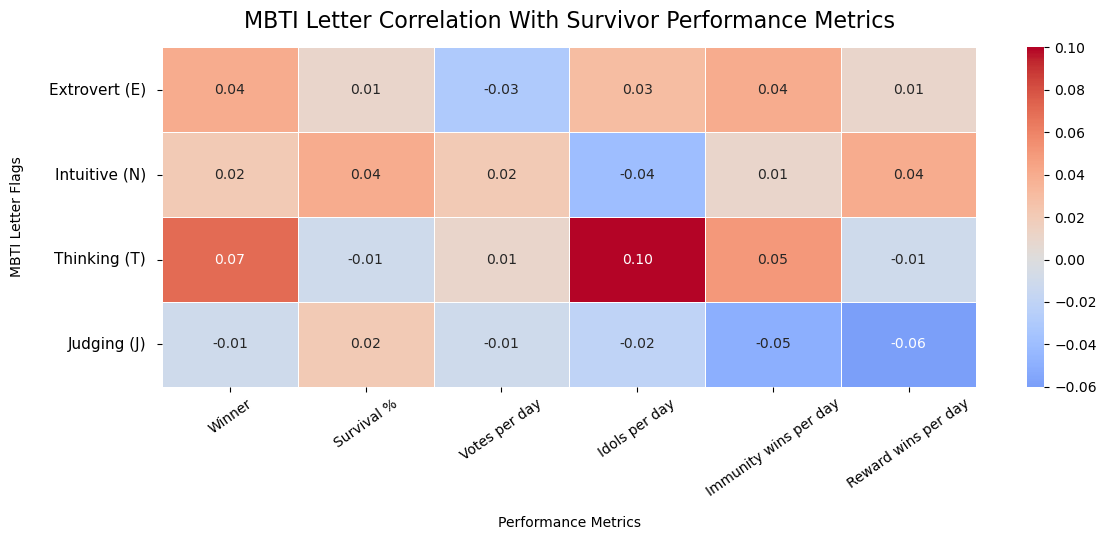

In [59]:
mbti_correlation_plot = mbti_correlation_focus.rename(
    index={
        "is_extrovert": "Extrovert (E)",
        "is_intuitive": "Intuitive (N)",
        "is_thinking": "Thinking (T)",
        "is_judging": "Judging (J)"
    },
    columns={
        "winner_flag": "Winner",
        "survival_pct": "Survival %",
        "votes_per_day": "Votes per day",
        "idols_per_day": "Idols per day",
        "immunity_wins_per_day": "Immunity wins per day",
        "reward_wins_per_day": "Reward wins per day"
    }
)

# Draw Heat Map
fig, ax = plt.subplots(figsize=(12, 5.5))

sns.heatmap(
    data=mbti_correlation_plot,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    "MBTI Letter Correlation With Survivor Performance Metrics",
    fontsize=16,
    pad=14
)

ax.set_xlabel("Performance Metrics", labelpad=12)
ax.set_ylabel("MBTI Letter Flags", labelpad=18)

ax.tick_params(axis="x", labelrotation=35, labelsize=10)
ax.tick_params(axis="y", labelrotation=0, labelsize=11, pad=8)

plt.tight_layout()
plt.show()

### MBTI Correlation Heatmap Observation

This heatmap compares MBTI letter dimensions against winner status and normalized Survivor performance metrics. I split each personality type into broader letter flags because the full four-letter MBTI groups are small, while the Extrovert/Introvert (E/I), Sensing/Intuitive (S/N), Thinking/Feeling (T/F), and Judging/Perceiving (J/P) dimensions give a cleaner view of the data.

The correlations are mostly weak, which means MBTI alone does not strongly explain who wins or performs well. Still, a few small patterns are worth noticing. Thinking types show the strongest positive relationship with winner status and idols per day, while judging types trend slightly lower across challenge-win metrics. These are not definitive conclusions, but they give us a useful starting point for asking better questions.

I also normalized votes, idols, and challenge wins by days survived because raw totals naturally favor players who lasted longer. That keeps the visual more objectively correct. Instead of treating personality as the be all and end all, this heatmap treats it as one measure among many being that of a small signal inside the much bigger social game.

In [58]:
print("MBTI heatmap rows:", len(mbti_heatmap_df))
print("\nColumns used:")
print(mbti_columns + metric_columns)

print("\nMissing values:")
print(mbti_heatmap_df[mbti_columns + metric_columns].isna().sum())

MBTI heatmap rows: 739

Columns used:
['is_extrovert', 'is_intuitive', 'is_thinking', 'is_judging', 'winner_flag', 'survival_pct', 'votes_per_day', 'idols_per_day', 'immunity_wins_per_day', 'reward_wins_per_day']

Missing values:
is_extrovert             0
is_intuitive             0
is_thinking              0
is_judging               0
winner_flag              0
survival_pct             0
votes_per_day            0
idols_per_day            0
immunity_wins_per_day    0
reward_wins_per_day      0
dtype: int64
